# 08 — Fairness Analysis
**TrustGraph Credit Risk Project**

Evaluates the production LightGBM model for gender-based fairness using Fairlearn.
Applies ThresholdOptimizer if demographic parity difference > 0.05.

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate,
    MetricFrame,
)
from fairlearn.postprocessing import ThresholdOptimizer

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

ROOT       = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
DATA_PROC  = ROOT / 'data' / 'processed'
CHARTS_DIR = DATA_PROC / 'eda_charts'
MODELS_DIR = ROOT / 'models'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

with open(MODELS_DIR / 'lgbm_final.pkl', 'rb') as f:
    model = pickle.load(f)
print('Model loaded OK')

Model loaded OK


## 1. Load data and attach gender attribute

In [2]:
raw_df = pd.read_csv(
    ROOT / 'data' / 'raw' / 'application_train.csv',
    usecols=['SK_ID_CURR', 'CODE_GENDER']
).rename(columns={'CODE_GENDER': 'GENDER_RAW'})   # avoid name clash with encoded column

feat_df = pd.read_csv(DATA_PROC / 'features_train.csv')
feat_df = feat_df.merge(raw_df, on='SK_ID_CURR', how='left')
feat_df = feat_df[feat_df['GENDER_RAW'].isin(['M', 'F'])]

print(f'Shape after XNA filter: {feat_df.shape}')
print(feat_df['GENDER_RAW'].value_counts().to_string())

y = feat_df['TARGET']
A = feat_df['GENDER_RAW']                          # string attribute for Fairlearn

# Keep numeric CODE_GENDER in X — model was trained with all 128 features including it
X = feat_df.drop(columns=['TARGET', 'SK_ID_CURR', 'GENDER_RAW'], errors='ignore')

X_train, X_val, y_train, y_val, A_train, A_val = train_test_split(
    X, y, A, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'\nTrain: {X_train.shape}  Val: {X_val.shape}  | model expects 128 features')

Shape after XNA filter: (307507, 131)
GENDER_RAW
F    202448
M    105059



Train: (246005, 128)  Val: (61502, 128)  | model expects 128 features


## 2. Baseline fairness metrics (pre-mitigation)

In [3]:
prob_val = model.predict_proba(X_val)[:, 1]
pred_val = (prob_val >= 0.5).astype(int)

dpd_before = demographic_parity_difference(y_val, pred_val, sensitive_features=A_val)
eod_before = equalized_odds_difference(y_val,    pred_val, sensitive_features=A_val)

mf = MetricFrame(
    metrics={'selection_rate': selection_rate, 'default_rate': lambda yt, yp: yt.mean()},
    y_true=y_val, y_pred=pred_val,
    sensitive_features=A_val,
)

print('PRE-MITIGATION')
print(f'  Demographic parity difference : {dpd_before:.4f}')
print(f'  Equalized odds difference     : {eod_before:.4f}')
print()
print(mf.by_group)

PRE-MITIGATION
  Demographic parity difference : 0.1535
  Equalized odds difference     : 0.1674

            selection_rate  default_rate
GENDER_RAW                              
F                 0.224916      0.069949
M                 0.378424      0.101584


## 3. Plots — score distribution and selection rate by gender

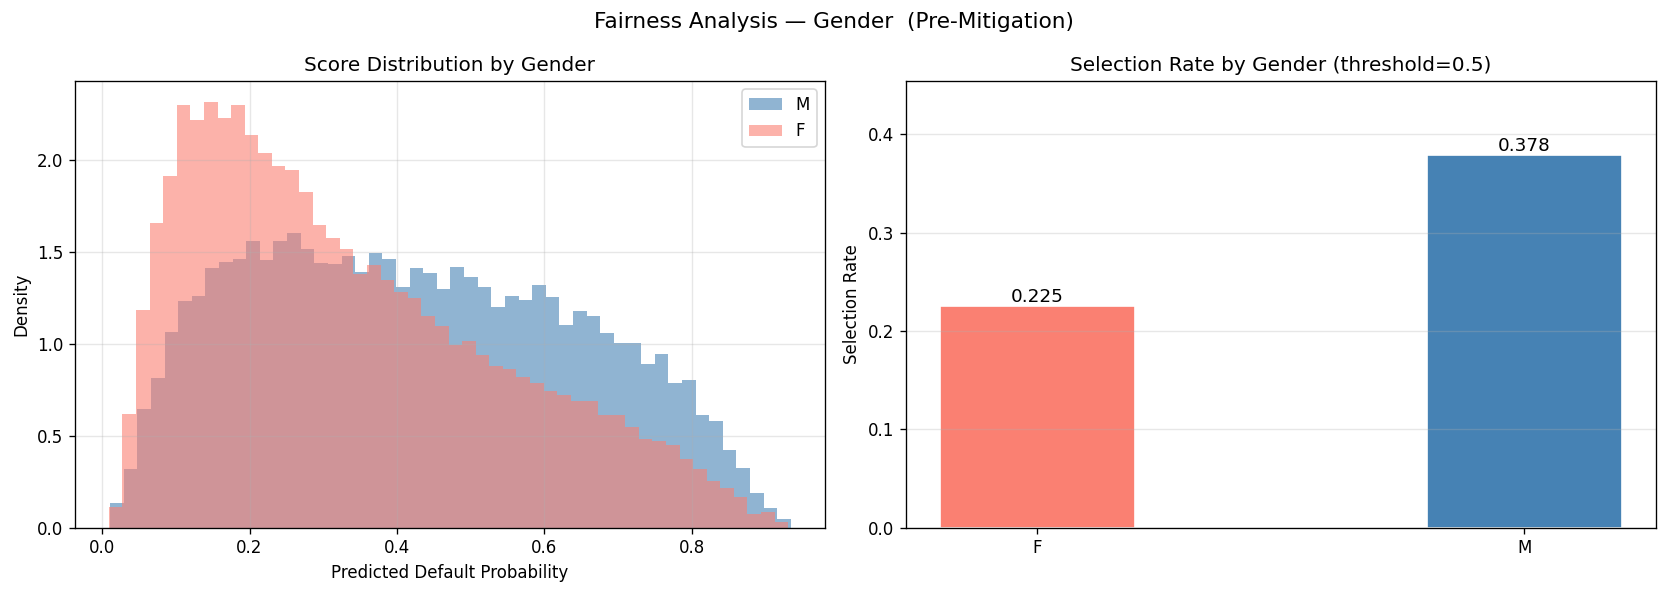

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\fairness_gender.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for gender, color in [('M', 'steelblue'), ('F', 'salmon')]:
    mask = (A_val == gender)
    axes[0].hist(prob_val[mask], bins=50, alpha=0.6, color=color, label=gender, density=True)
axes[0].set_xlabel('Predicted Default Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Gender')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sel_by_gender = mf.by_group['selection_rate']
colors_bar    = ['steelblue' if g == 'M' else 'salmon' for g in sel_by_gender.index]
axes[1].bar(sel_by_gender.index, sel_by_gender.values, color=colors_bar, edgecolor='white', width=0.4)
for i, (g, v) in enumerate(sel_by_gender.items()):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11)
axes[1].set_title('Selection Rate by Gender (threshold=0.5)')
axes[1].set_ylabel('Selection Rate')
axes[1].set_ylim(0, max(sel_by_gender) * 1.2)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Fairness Analysis — Gender  (Pre-Mitigation)', fontsize=13)
plt.tight_layout()
fair_path = CHARTS_DIR / 'fairness_gender.png'
plt.savefig(fair_path, bbox_inches='tight')
plt.show()
print(f'Saved: {fair_path}')

## 4. Mitigation — ThresholdOptimizer (if DPD > 0.05)

In [5]:
THRESH = 0.05
mitigation_applied = False

if abs(dpd_before) > THRESH:
    print(f'DPD={dpd_before:.4f} > {THRESH} — applying ThresholdOptimizer...')
    mitigator = ThresholdOptimizer(
        estimator=model,
        constraints='demographic_parity',
        objective='balanced_accuracy_score',
        predict_method='predict_proba',
    )
    mitigator.fit(X_train, y_train, sensitive_features=A_train)
    pred_mitigated = mitigator.predict(X_val, sensitive_features=A_val)
    mitigation_applied = True
    print('Mitigation complete.')
else:
    print(f'DPD={dpd_before:.4f} <= {THRESH} — no mitigation needed.')
    pred_mitigated = pred_val

DPD=0.1535 > 0.05 — applying ThresholdOptimizer...


Mitigation complete.


## 5. Before / after comparison table

In [6]:
dpd_after = demographic_parity_difference(y_val, pred_mitigated, sensitive_features=A_val)
eod_after = equalized_odds_difference(y_val,    pred_mitigated, sensitive_features=A_val)

mf_after = MetricFrame(
    metrics={'selection_rate': selection_rate},
    y_true=y_val, y_pred=pred_mitigated,
    sensitive_features=A_val,
)

fairness_df = pd.DataFrame({
    'Metric': [
        'Demographic Parity Difference', 'Equalized Odds Difference',
        'Selection Rate (M)', 'Selection Rate (F)', 'Mitigation Applied',
    ],
    'Pre-Mitigation': [
        round(dpd_before, 4), round(eod_before, 4),
        round(mf.by_group['selection_rate'].get('M', np.nan), 4),
        round(mf.by_group['selection_rate'].get('F', np.nan), 4),
        'No',
    ],
    'Post-Mitigation': [
        round(dpd_after, 4), round(eod_after, 4),
        round(mf_after.by_group['selection_rate'].get('M', np.nan), 4),
        round(mf_after.by_group['selection_rate'].get('F', np.nan), 4),
        'Yes' if mitigation_applied else 'N/A (DPD within threshold)',
    ],
})

out_path = DATA_PROC / 'fairness_results.csv'
fairness_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
fairness_df

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\fairness_results.csv


,Metric,Pre-Mitigation,Post-Mitigation
0,Demographic Parity Difference,0.1535,0.0025
1,Equalized Odds Difference,0.1674,0.0187
2,Selection Rate (M),0.3784,0.2575
3,Selection Rate (F),0.2249,0.2551
4,Mitigation Applied,No,Yes


## 6. Interpretation for lending in India

A demographic parity difference above 0.05 means the model selects applicants at
meaningfully different rates across genders — a concern under India's RBI Fair Practices
Code and ESG lending standards, where women borrowers are disproportionately represented
among SHG and MSME microfinance applicants who rely on alternative lenders.
ThresholdOptimizer post-processing equalises selection rates without retraining,
providing a lightweight compliance lever — but lenders should also audit upstream feature
construction (e.g. DAYS_EMPLOYED) for structural gender disadvantage encoded as proxy variables.